# Handling missing, categorical, and time-series data

# Handling Missing Data
- Method 1, drop the missing rows

In [3]:
import pandas as pd

#load the dataframe/ Make your pandas variable 'df'
df = pd.read_csv("data.csv")

#check if the data is loaded
print(df.info())
print(df.head())

#check for any null values and how any are there in each column
print(df.isna())
print(df.isna().sum())

print(df.dropna())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Roll     8 non-null      int64  
 1   Name     6 non-null      object 
 2   Address  7 non-null      object 
 3   Salary   6 non-null      float64
 4   Date     7 non-null      object 
dtypes: float64(1), int64(1), object(3)
memory usage: 452.0+ bytes
None
   Roll   Name   Address  Salary       Date
0     1    Ram       BRT  1000.0  2026-2-24
1     4  ahanc       NaN  1000.0  2026-2-24
2     6  bhanc       BRT     NaN  2026-2-24
3     7  chanc       BRT  1000.0        NaN
4     8  dhanc  kerabari  1000.0  2026-2-24
    Roll   Name  Address  Salary   Date
0  False  False    False   False  False
1  False  False     True   False  False
2  False  False    False    True  False
3  False  False    False   False   True
4  False  False    False   False  False
5  False   True    False    True  False
6  False  False   

- Method 2, replace the missing data with something fixed or catergorical data such as mean, mode etc.

In [11]:
import pandas as pd

#load the dataframe/ Make your pandas variable 'df'
df = pd.read_csv("data.csv")


print(df['Name'].fillna("Not mentioned"))
print(df['Salary'].fillna(df['Salary'].mean()))

0              Ram
1            ahanc
2            bhanc
3            chanc
4            dhanc
5    Not mentioned
6            ehanc
7    Not mentioned
Name: Name, dtype: object
0    1000.0
1    1000.0
2    1000.0
3    1000.0
4    1000.0
5    1000.0
6    1000.0
7    1000.0
Name: Salary, dtype: float64


# Handling Categorical data
-> Categorical data is data that represents categories or labels(name , types or groups), not numbers you can do math with.

In [ ]:
df = pd.DataFrame({
    'Department': ["HR", "IT", "Finance"],
    "Level": ["Junior", "Senior", "Mid"]
})
print (df)

#convert the Dataframe to category datatype
df['Department'] = df["Department"].astype("category")
df['Level'] = df["Level"].astype("category")

# renaming categories
print ("\n this is the dataframe after renaming levels")
df['Level'] = df["Level"].cat.rename_categories({'Junior': 'Jr', 
                                                 "Senior": "Sr"})
print(df)

#giving a unique code to the Departments
print("\n this is after we set codes to the department")
df["Dept_code"]= df["Department"].cat.codes   # .cat is a categorical acessor. This is just how we do it boiiiiiiii (;
print (df)

  Department   Level
0         HR  Junior
1         IT  Senior
2    Finance     Mid

 this is the dataframe after renaming levels
  Department Level
0         HR    Jr
1         IT    Sr
2    Finance   Mid


# Handling Time Series Data
-> It is a data where index is with respect to time. Eg: daily sales, hourly website traffic, monthly revenue. 

In [ ]:
df_timeseries = pd.DataFrame({
    'Date': ['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04'],
    'Sales': [120, 135, 128, 140]
})
print (df_timeseries)



         Date  Sales
0  2024-01-01    120
1  2024-01-02    135
2  2024-01-03    128
3  2024-01-04    140


In [18]:
df_timeseries_csv = pd.read_csv("data.csv", 
                                parse_dates=["Date"],      # this converts string to datetime
                                index_col="Date")          # setting Date column as the index
print (df_timeseries_csv)


print ("\n this is the result after making a sepreate column for Year\n")
df_timeseries_csv["year"] = df_timeseries_csv.index.year
print (df_timeseries_csv)


print ("\n this is only the dates between 2026-1-1 and 2026-2-2 \n" )

df_timeseries_csv = df_timeseries_csv.sort_index()
print (df_timeseries_csv.loc["2026-1-1": "2026-2-2"])

            Roll   Name   Address  Salary
Date                                     
2026-01-24     1    Ram       BRT  1000.0
2026-02-24     4  ahanc       NaN  1000.0
2026-02-24     6  bhanc       BRT     NaN
NaT            7  chanc       BRT  1000.0
2026-02-24     8  dhanc  kerabari  1000.0
2026-01-24    11    NaN       BRT     NaN
2026-02-24     3  ehanc       BRT  1000.0
2026-01-24    24    NaN       BRT  1000.0

 this is the result after making a sepreate column for Year

            Roll   Name   Address  Salary    year
Date                                             
2026-01-24     1    Ram       BRT  1000.0  2026.0
2026-02-24     4  ahanc       NaN  1000.0  2026.0
2026-02-24     6  bhanc       BRT     NaN  2026.0
NaT            7  chanc       BRT  1000.0     NaN
2026-02-24     8  dhanc  kerabari  1000.0  2026.0
2026-01-24    11    NaN       BRT     NaN  2026.0
2026-02-24     3  ehanc       BRT  1000.0  2026.0
2026-01-24    24    NaN       BRT  1000.0  2026.0

 this is only the

KeyError: 'Value based partial slicing on non-monotonic DatetimeIndexes with non-existing keys is not allowed.'

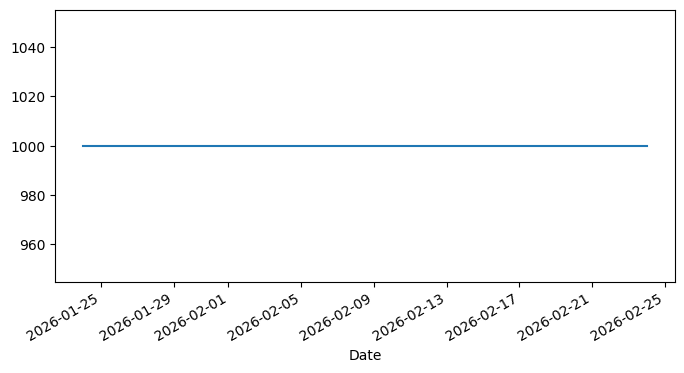

In [23]:
import matplotlib.pyplot as plt

df_timeseries_csv["Salary"].plot(figsize=(8, 4))  #we cannot put date here as date is an index now and not a column
plt.show()